<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-hw-3?scriptVersionId=295466521" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [78]:
import torch  
from torchvision import datasets, transforms 

In [79]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
dataset = datasets.ImageFolder(data_dir)

In [80]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [81]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [82]:
img, label = data_train[2000]

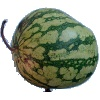

In [83]:
img

In [84]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [85]:
train_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
     transforms.ToTensor()
    ] 
)

In [86]:
train_transform(img).shape

torch.Size([3, 200, 200])

In [87]:
test_transform(img).shape

torch.Size([3, 200, 200])

In [88]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [89]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [90]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [91]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([42, 3, 200, 200])
torch.Size([42])


(200, 200, 3)


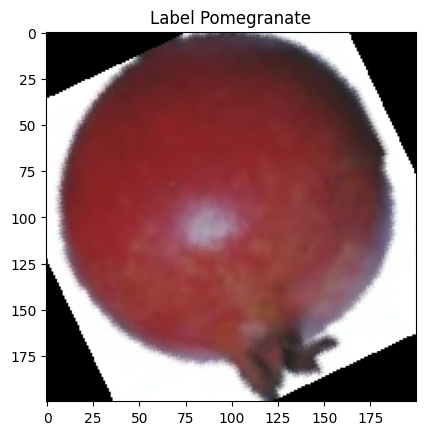

(200, 200, 3)


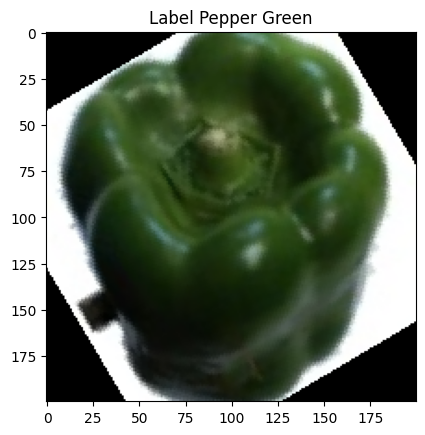

(200, 200, 3)


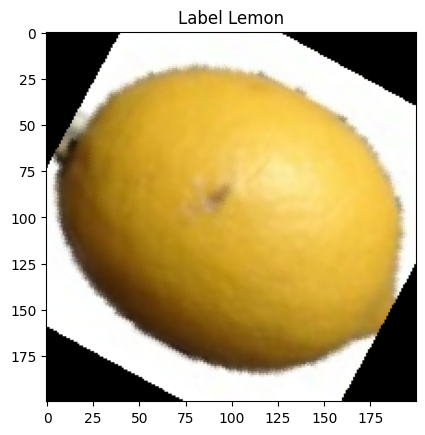

In [92]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

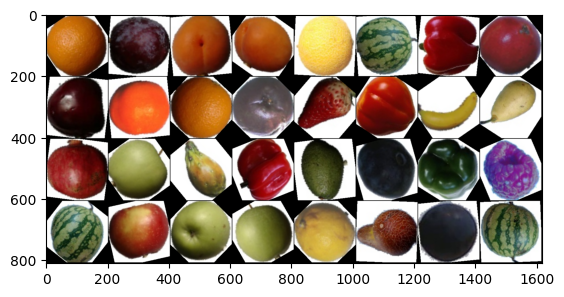

In [93]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [94]:
img, label = train_data[0]

img.shape

torch.Size([3, 200, 200])

In [95]:
3*200*200

120000

In [96]:
len(dataset.classes)

33

In [100]:
# from torch import nn

# #нейромережа
# model = nn.Sequential(
#     nn.Flatten(),   # переведе зображення 3х64х64 в нейрони 12288
#     nn.Linear(12288, 128),   # на вході 12288 нейронів передає інформацію 64 нейронам
#     nn.ReLU(),
#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Linear(64, 33)   # 33 нейрона на кожен тип фрукта
# )


# підключення до процесора
device = 'cuda'
model = model.to(device)

3*200*200


from torch import nn

# Створення моделі
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),  # 8, 200, 200
    nn.ReLU(),
    nn.MaxPool2d(2, 2),    # 8, 100, 100
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),  # 16, 100, 100
    nn.ReLU(),
    nn.MaxPool2d(2, 2),    # 16, 50, 50
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), # 32, 50, 50
    nn.ReLU(),
    nn.MaxPool2d(2, 2),  # 32, 25, 25

    nn.Flatten(),  # 32*25*25 = 20000
    nn.Linear(20000, 32),
    nn.ReLU(),
    nn.Linear(32, 33)  # ← 33 класи фруктів
)


device = 'cuda'
model = model.to(device)


In [101]:
for imgs, labels in train_loader:
    break

In [102]:
imgs.shape

torch.Size([256, 3, 200, 200])

In [105]:
imgs = imgs.to(device)
res = model(imgs)
res.shape

torch.Size([256, 33])

In [109]:
# Взяти одне зображення з тестового набору
img, label = test_data[0]
img = img.unsqueeze(0).to(device)

# Передбачення
result = model(img)
predicted_class = result.argmax(dim=1).item()

print(f"Справжній клас: {label}")
print(f"Передбачений клас: {predicted_class}")
print(f"Назва: {dataset.classes[predicted_class]}")


Справжній клас: 13
Передбачений клас: 30
Назва: Strawberry


In [107]:
#ймовірності
probs = nn.Softmax()(result)
probs

tensor([[0.0306, 0.0291, 0.0305, 0.0322, 0.0266, 0.0320, 0.0292, 0.0334, 0.0270,
         0.0320, 0.0335, 0.0294, 0.0292, 0.0278, 0.0284, 0.0289, 0.0344, 0.0295,
         0.0283, 0.0306, 0.0333, 0.0344, 0.0319, 0.0312, 0.0259, 0.0270, 0.0264,
         0.0294, 0.0333, 0.0279, 0.0349, 0.0318, 0.0297]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [108]:
label

27

**# Визначення функції втрат та оптимізатора**

In [110]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),   
    lr=0.001
)

loss_list = []
loss_test_list = []
for i in range(10):
    
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 3.496750593185425
loss: 3.5014536380767822
loss: 3.4915080070495605
loss: 3.5073485374450684
loss: 3.4733948707580566
loss: 3.487297534942627
loss: 3.4713146686553955
loss: 3.4667177200317383
loss: 3.45613431930542
loss: 3.423534631729126
loss: 3.4251768589019775
loss: 3.393178939819336
loss: 3.350139617919922
loss: 3.3300533294677734
loss: 3.322096347808838
loss: 3.285860061645508
loss: 3.2820162773132324
loss: 3.252199649810791
loss: 3.157349109649658
loss: 3.193301200866699
loss: 3.12082839012146
loss: 2.9898128509521484
loss: 3.100743532180786
loss: 2.993847370147705
loss: 3.0754690170288086
loss: 2.928187847137451
loss: 2.9024171829223633
loss: 3.0502500534057617
loss: 2.9870405197143555
loss: 2.8996760845184326
loss: 2.824664831161499
loss: 2.9827017784118652
loss: 2.8118033409118652
loss: 2.7564830780029297
loss: 2.780186176300049
loss: 2.605527400970459
loss: 2.670022487640381
loss: 2.6443185806274414
loss: 2.54435658454895
loss: 2.548569679260254
loss: 2.5386548042297363

In [111]:
img, label = train_data[0]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(nn.Softmax()(prediction))

27
tensor([[2.6975e-07, 1.5451e-13, 2.5255e-12, 9.8610e-17, 8.1656e-07, 2.8770e-26,
         1.1160e-08, 4.7463e-19, 4.9465e-15, 2.1432e-20, 7.9157e-19, 2.3124e-03,
         2.5602e-15, 3.1913e-07, 8.8620e-18, 2.8016e-31, 1.8730e-24, 5.4552e-05,
         3.7557e-15, 3.6544e-11, 9.6589e-24, 3.4686e-09, 1.8849e-06, 6.6201e-14,
         2.3872e-10, 6.1869e-04, 1.9864e-13, 9.9700e-01, 6.8545e-13, 2.3313e-19,
         7.0459e-06, 1.6820e-18, 2.5976e-15]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


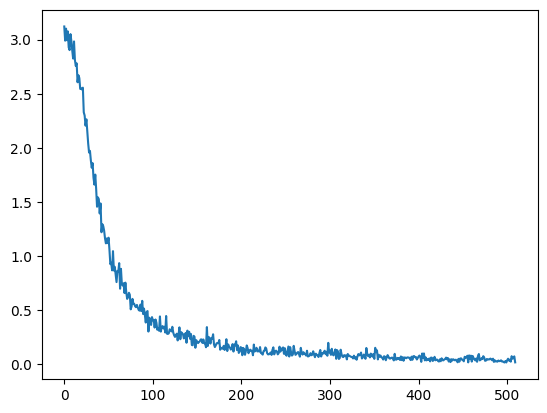

In [112]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)

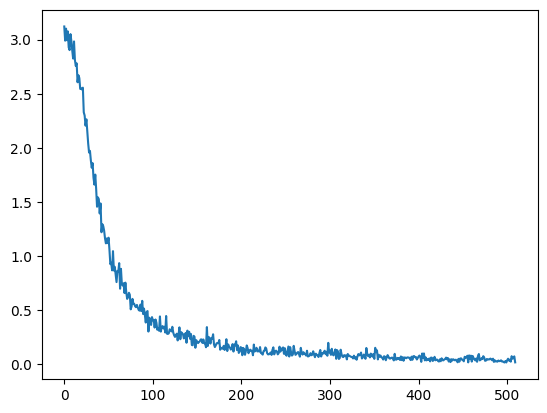

In [113]:
plt.plot(new_list)

In [115]:
imgs.shape

torch.Size([42, 3, 200, 200])

In [121]:
result = model(imgs)

In [132]:
result.argmax(dim=1)

tensor([27,  5, 11, 27, 22, 25, 24,  6, 22, 22, 24, 18,  9,  0,  3,  6, 15, 16,
         6, 30, 16,  7, 11, 32,  3,  2, 20,  6,  0, 25, 23, 14, 15, 18, 12, 30,
        12, 31, 27, 27,  5, 29], device='cuda:0')

In [123]:
labels

tensor([27,  5, 11, 27, 22, 25, 24,  4, 22, 22, 24, 18,  9,  0,  3,  6, 15, 16,
         6, 30, 16,  7, 11, 32,  3,  2, 20, 17,  0, 25, 23, 14, 15, 18, 12, 30,
        12, 31, 27, 27,  5, 29], device='cuda:0')

In [133]:
res1 = result.argmax(dim=1)
res2 = res1 == labels

In [134]:
res2.sum()

tensor(40, device='cuda:0')

In [135]:
40/41

0.975609756097561

In [139]:
count = 0
for imgs, labels in test_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count)
print(f"Всього test: {len(test_data)}")
print(f"Accuracy: {count/len(test_data):.4f}")

3295
Всього test: 3370
Accuracy: 0.9777


In [140]:
count = 0
for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count)
print(f"Всього test: {len(train_data)}")
print(f"Accuracy: {count/len(train_data):.4f}")

13195
Всього test: 13484
Accuracy: 0.9786
